# Tutorial 3/3 -- Frequency View and a First Stable Fix (Optional)
### From high-pass insight to fitting all the data at once

**Recap of Parts 1–2.** Clean data: FDM inverse exact to ~$10^{-14}$. With 1% noise on 101 points,
noise in $T''$ is ~$306$ vs signal $-10$ (~30x); ~half of $\alpha$ estimates are negative;
refining the mesh multiplies noise by 4x per halving of $\Delta x$; even round-off obeys the same law.

**Learning goals (Part 3).** After this notebook you can:
1. Explain differentiation as a high-pass amplifier (gain $k^2$, up to $4/\Delta x^2$).
2. Implement the derivative-free global least-squares fit and show it reaches ~0.1% at 1% noise.
3. State the honest caveat (physics smuggled in via the model) and name the next steps (regularization, PINNs).




## 0. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.titlesize": 12,
})

# Problem parameters (same in all three tutorials of this series)
L = 1.0
q = 1.0
T0 = 0.0
TL = 0.0
alpha_true = 0.1

Txx_true = -q / alpha_true   # exact (constant) curvature we hope to recover

print(f"L = {L}, q = {q}, T0 = {T0}, TL = {TL}")
print(f"True alpha = {alpha_true}   ->   true T'' = {Txx_true}")


def analytical_temperature(x, alpha, L=1.0, q=1.0, T0=0.0, TL=0.0):
    # Exact solution of -alpha*T'' = q with Dirichlet boundary conditions.
    return T0 + (TL - T0) * x / L + (q / (2 * alpha)) * x * (L - x)


def fdm_second_derivative(T, dx):
    return (T[2:] - 2 * T[1:-1] + T[:-2]) / dx**2


def inverse_alpha_fdm(T, dx, q=1.0):
    Txx = fdm_second_derivative(T, dx)
    return -q / Txx, Txx


def add_noise(T, relative_noise, seed=42):
    rng = np.random.default_rng(seed)
    sigma = relative_noise * np.max(np.abs(T))
    return T + rng.normal(0.0, sigma, T.shape), sigma

# Default grid used in this tutorial
x = np.linspace(0.0, L, 101)
T_true = analytical_temperature(x, alpha_true, L, q, T0, TL)
dx = x[1] - x[0]
Ns = [21, 41, 81, 161, 321, 641]


L = 1.0, q = 1.0, T0 = 0.0, TL = 0.0
True alpha = 0.1   ->   true T'' = -10.0


## 10. The deeper reason: the frequency view

A smooth signal varies slowly (low wavenumber $k$); measurement noise is jagged (it contains high $k$ all the way up to the grid limit). Differentiation acts differently on each:

$$
\frac{d^2}{dx^2}e^{ikx}=-k^2\,e^{ikx}.
$$

The second derivative multiplies a component with wavenumber $k$ by $k^2$. On a grid, the 3-point stencil multiplies it by

$$
\Big|\tfrac{2\cos(k\Delta x)-2}{\Delta x^2}\Big|=\frac{4}{\Delta x^2}\sin^2\!\Big(\tfrac{k\Delta x}{2}\Big),
$$

which reaches its maximum $4/\Delta x^2$ at the shortest wavelength the grid can represent (the Nyquist limit, $k\Delta x=\pi$).

**What to look for:** the signal lives at the far left of the plot (gain $\approx 10$); the noise is spread over *all* $k$, much of it where the gain is thousands of times larger.

> **Note.** Our $T(x)=5x(1-x)$ is not a single Fourier mode; "$k\approx\pi$" means its *dominant* sine-series mode $\sin(\pi x)$ on $[0,1]$ with Dirichlet ends. The exact gain on that mode is $\pi^2\approx 9.9$.


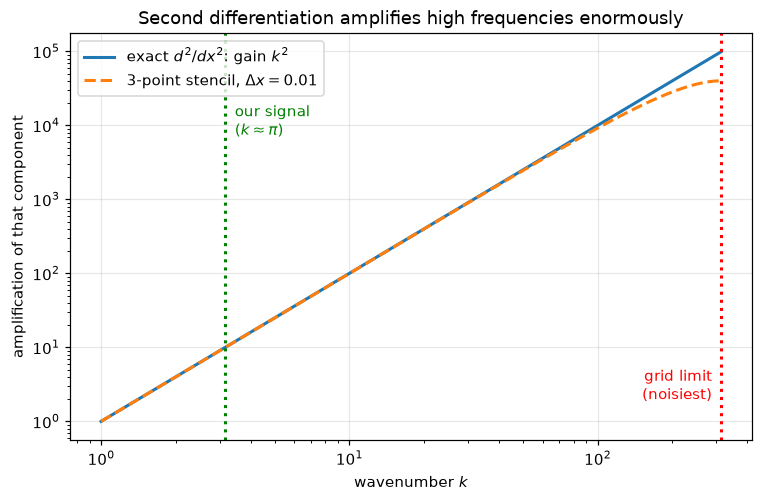

gain on our signal (k = pi)       : 9.9
gain at the grid limit (stencil)  : 40000


In [2]:
dx_demo = 0.01
k = np.logspace(0, np.log10(np.pi / dx_demo), 400)
gain_exact = k**2
gain_fd = 4 / dx_demo**2 * np.sin(k * dx_demo / 2) ** 2

plt.figure(figsize=(8, 4.8))
plt.loglog(k, gain_exact, lw=2, label=r"exact $d^2/dx^2$: gain $k^2$")
plt.loglog(k, gain_fd, "--", lw=2, label=r"3-point stencil, $\Delta x=0.01$")
plt.axvline(np.pi, color="g", ls=":", lw=2)
plt.text(np.pi * 1.1, 2e4, "our signal\n($k\\approx\\pi$)", color="g", va="top")
plt.axvline(np.pi / dx_demo, color="r", ls=":", lw=2)
plt.text(np.pi / dx_demo * 0.92, 2, "grid limit\n(noisiest)", color="r", ha="right")
plt.xlabel("wavenumber $k$"); plt.ylabel("amplification of that component")
plt.title("Second differentiation amplifies high frequencies enormously")
plt.legend(loc="upper left"); plt.show()

print(f"gain on our signal (k = pi)       : {np.pi**2:.1f}")
print(f"gain at the grid limit (stencil)  : {4/dx_demo**2:.0f}")

> **In one sentence:** differentiation is a *high-pass amplifier*. The signal we want is at low frequency, the noise is at high frequency, and the operator boosts exactly the part we do not want.

## 11. A first fix: use all the data at once

The failure was not caused by a lack of information. The 101 noisy measurements contain plenty of information about $\alpha$. The failure comes from throwing most of it away by treating every grid point as an independent mini-experiment that requires a derivative.

Recall the derivative-free inverse from Section 3: for our boundary conditions $T(x)=c\,\varphi(x)$ with $\varphi(x)=x(L-x)$ and $c=q/(2\alpha)$. Instead of differentiating, **fit the single number $c$ to all measurements by least squares**:

$$
\hat c=\frac{\sum_i \varphi_i\,T_i^{\rm obs}}{\sum_i \varphi_i^2},
\qquad
\boxed{\hat\alpha=\frac{q}{2\hat c}} .
$$

Two things make this far more stable: we never differentiate noisy data, and averaging over $N$ points reduces the noise by a factor $\sim\sqrt N$ (so *more data now helps*, the opposite of Section 8).

In [3]:
def global_fit_alpha(T_obs, xx):
    # Least-squares fit of T ~ c * x(L-x) (valid for T0 = TL = 0); works on 1-D or (trials, N) arrays.
    phi = xx * (L - xx)
    c_hat = (T_obs @ phi) / (phi @ phi)
    return q / (2 * c_hat)

# --- effect of noise level (N = 101)
print("Global fit, N = 101, 500 noise realisations each")
print(f"{'noise':>6} {'mean alpha':>12} {'std alpha':>11} {'rel. error (std/alpha)':>24}")
rng = np.random.default_rng(1)
for eta in [0.01, 0.05, 0.10]:
    sig = eta * T_true.max()
    Tn = T_true + rng.normal(0, sig, (500, x.size))
    a_hat = global_fit_alpha(Tn, x)
    print(f"{eta:6.0%} {a_hat.mean():12.4f} {a_hat.std():11.4f} {a_hat.std()/alpha_true:24.1%}")

Global fit, N = 101, 500 noise realisations each
 noise   mean alpha   std alpha   rel. error (std/alpha)
    1%       0.1000      0.0001                     0.1%
    5%       0.1000      0.0007                     0.7%
   10%       0.1000      0.0014                     1.4%


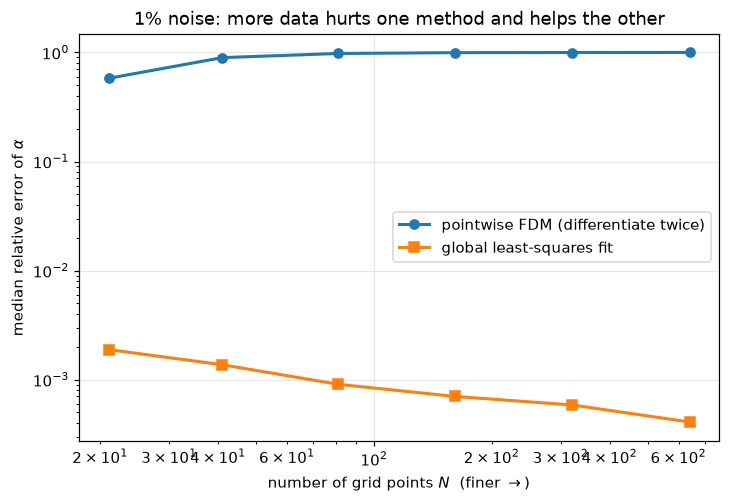

median relative error |alpha_hat - alpha_true| / alpha_true (NOT the 'usable %' of Tutorial 2):
N =   21   pointwise med-rel-err:   57.9%    global-fit med-rel-err:   0.19%
N =   41   pointwise med-rel-err:   89.6%    global-fit med-rel-err:   0.14%
N =   81   pointwise med-rel-err:   97.8%    global-fit med-rel-err:   0.09%
N =  161   pointwise med-rel-err:   99.6%    global-fit med-rel-err:   0.07%
N =  321   pointwise med-rel-err:   99.9%    global-fit med-rel-err:   0.06%
N =  641   pointwise med-rel-err:  100.0%    global-fit med-rel-err:   0.04%


In [4]:
# --- effect of grid refinement (1% noise): pointwise FDM vs global fit
def mc_pointwise(N, eta=0.01, trials=200, seed=0):
    xx = np.linspace(0, L, N)
    ddx = xx[1] - xx[0]
    TT = analytical_temperature(xx, alpha_true, L, q, T0, TL)
    sig = eta * TT.max()
    rng = np.random.default_rng(seed + N)
    Tn = TT + rng.normal(0.0, sig, (trials, N))
    Txx = (Tn[:, 2:] - 2 * Tn[:, 1:-1] + Tn[:, :-2]) / ddx**2
    a = -q / Txx
    return np.median(np.abs(a - alpha_true) / alpha_true)


def mc_global(N, eta=0.01, trials=200, seed=0):
    xx = np.linspace(0, L, N)
    TT = analytical_temperature(xx, alpha_true, L, q, T0, TL)
    # Same seed+N scheme: paired noise with pointwise within each N, independent across N.
    rng = np.random.default_rng(seed + N)
    Tn = TT + rng.normal(0.0, eta * TT.max(), (trials, N))
    a = global_fit_alpha(Tn, xx)
    return np.median(np.abs(a - alpha_true) / alpha_true)

pointwise_err = [mc_pointwise(N) for N in Ns]
global_err = [mc_global(N) for N in Ns]

plt.figure(figsize=(7.5, 4.8))
plt.loglog(Ns, pointwise_err, "o-", lw=2, label="pointwise FDM (differentiate twice)")
plt.loglog(Ns, global_err, "s-", lw=2, label="global least-squares fit")
plt.xlabel("number of grid points $N$  (finer $\\rightarrow$)")
plt.ylabel(r"median relative error of $\alpha$")
plt.title("1% noise: more data hurts one method and helps the other")
plt.legend(); plt.show()

print("median relative error |alpha_hat - alpha_true| / alpha_true (NOT the 'usable %' of Tutorial 2):")
for N, p, g in zip(Ns, pointwise_err, global_err):
    print(f"N = {N:4d}   pointwise med-rel-err: {p:7.1%}    global-fit med-rel-err: {g:7.2%}")


**Result.** The global fit recovers $\alpha$ to within a few percent or better, even with 10% noise, and it keeps improving as we add points. The pointwise estimator has a typical (median) error of 60% on the coarsest grid, rising to essentially 100% on the finest: it gets worse as we add data.

> **The honest caveat.** The global fit works so well because we assumed the *form* of the solution ($T\propto x(L-x)$), which is the physics smuggled in through the model. That is precisely the idea behind the methods in the "next steps" below: **put the governing equation into the estimator** instead of differentiating the data pointwise. For realistic problems (unknown or variable $\alpha(x)$, complicated geometry) the model form is not known in closed form, and regularized inversion or PINNs provide the machinery.

## 12. Summary

### What we did

1. Derived the exact forward solution $T(x)=\frac{q}{2\alpha}x(L-x)$ and the exact inverse $\alpha=-q/T''$.
2. Verified that the finite-difference inverse is essentially perfect on clean data.
3. Added realistic measurement noise ($\epsilon_i\sim\mathcal N(0,\sigma^2)$) and saw that the data still looked fine.
4. Showed analytically **and numerically** that the second difference turns noise of size $\sigma$ into noise of size $\sqrt6\,\sigma/\Delta x^{2}$.
5. Watched the naive inverse fail, and watched it fail *more* on finer grids.
6. Ran a noise-free control: the stencil is not buggy; even round-off follows the same law.
7. Explained the mechanism in frequency space, then showed a global fit that works.

### Key results (1% noise, 101 points, $\alpha_{\rm true}=0.1$)

| Quantity | Value |
|---|---|
| Std of noise in $T''$ (theory = measured) | $\approx 306$ |
| True $T''$ | $-10$ |
| Noise-to-signal ratio in $T''$ | $\approx 30$ |
| Pointwise $\alpha$ estimates with the wrong (negative) sign | about half (48%) |
| Pointwise estimates within $\pm50\%$ of truth | about 6% |
| Noise growth when $\Delta x$ is halved | 4x |
| Global least-squares fit, relative error in $\alpha$ | about 0.1% (1.4% even at 10% noise) |

### Why it fails: three ingredients

$$
\boxed{\text{noisy data}\;+\;\text{second differentiation}\;+\;\text{division by the result}}
$$

* **Differentiation** is a high-pass amplifier: gain $\sim k^2$, up to $4/\Delta x^2$ on the grid.
* **Fixed sensor noise** does not shrink with $\Delta x$, so refining the mesh only increases the gain.
* **Division by a noisy, sign-changing $T''$** produces huge outliers and negative values.

### Practical lessons

* A finer grid is not automatically a better inverse. Noise sets the useful resolution.
* Look at $T''$ (the differentiated quantity), not just $\alpha$. And do not trust a single summary metric such as RMSE (Section 8).
* Do not estimate a global constant from pointwise derivatives of noisy data. Fit it from all the data at once.
* "FDM is broken" is the wrong conclusion. The right one is: **direct numerical differentiation of noisy measurements is an ill-conditioned operation.**

### Where to go next

**Step 1: regularized global inverse.** Trade off data fit against the physics:

$$
\min_{\alpha,\,T}\;\; \lambda_d\,\|T-T^{\rm obs}\|^2+\lambda_p\,\|-\alpha T''-q\|^2 .
$$

**Step 2: PINN inverse.** Represent $T_\theta(x)$ with a neural network, treat $\alpha$ as a trainable parameter, and minimise

$$
\mathcal L=\lambda_{\rm data}\,\mathcal L_{\rm data}+\lambda_{\rm PDE}\,\mathcal L_{\rm PDE},
\qquad
r_\theta=-\alpha\,T_\theta''-q .
$$

The overall progression:

$$
\text{analytical inverse}\to\text{FDM inverse}\to\text{noise amplification}\to\text{regularization}\to\text{PINN inverse}.
$$

### Exercises

1. **Noise level.** Repeat Section 8 with $\eta=0.1\%$. At what grid spacing does the noise in $T''$ equal the true $|T''|=10$? (Hint: solve $\sqrt6\,\sigma/\Delta x^2=10$.)
2. **Smoothing.** Smooth $T^{\rm obs}$ with a moving average before differentiating. Does it help? What happens to the bias near the peak?
3. **Truncation vs. noise.** Replace the source by $q(x)=\pi^2\sin(\pi x)$ with $\alpha=0.1$ so that $T$ is not a polynomial, and plot the total error versus $\Delta x$. Can you see the optimal $\Delta x$ from the caveat in Section 9?
4. **Different noise.** Replace independent Gaussian noise by noise that is correlated between neighbouring points. How does $\operatorname{Std}(\epsilon_{T''})$ change?